In [32]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/processed/DELHI_MASTER_AQI_WEATHER_2025.csv")

df["datetime"] = pd.to_datetime(df["datetime"])

df = df[[
    "datetime",
    "station",
    "aqi",
    "wind_speed_ms",
    "wind_dir_deg"
]]

df = df.dropna().reset_index(drop=True)

In [33]:
df["wind_x"] = np.cos(np.deg2rad(df["wind_dir_deg"]))
df["wind_y"] = np.sin(np.deg2rad(df["wind_dir_deg"]))

In [34]:
df_pivot = df.pivot_table(
    index="datetime",
    columns="station",
    values="aqi",
    aggfunc="mean"
)

df_pivot = df_pivot.sort_index()
df_pivot = df_pivot.fillna(method="ffill")

C:\Users\Lakshay Pal\AppData\Local\Temp\ipykernel_11884\1525046620.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pivot = df_pivot.fillna(method="ffill")


In [60]:
df = df_pivot.copy()
df = df.dropna()

# convert index → column
df = df.reset_index()

# now datetime exists
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["month"] = df["datetime"].dt.month

# drop datetime after feature extraction
df = df.drop(columns=["datetime"])

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [52]:
sequence_length = 72

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i][0])  # AQI target

X = np.array(X)
y = np.array(y)

print(X.shape)

(144576, 72, 5)


In [43]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))

model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

d:\IOTMODEL\MODEL\Delhi_AQI_Predictor\AQI_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [66]:
model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/25
3616/3616 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 0.0017 - val_loss: 0.0070
Epoch 2/25
3616/3616 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 0.0015 - val_loss: 0.0087
Epoch 3/25
3616/3616 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 0.0014 - val_loss: 0.0087
Epoch 4/25
3616/3616 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 0.0013 - val_loss: 0.0076
Epoch 5/25
3616/3616 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 0.0012 - val_loss: 0.0062
Epoch 6/25
3616/3616 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 0.0011 - val_loss: 0.0066
Epoch 7/25
3616/3616 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 0.0010 - val_loss: 0.0077
Epoch 8/25
3616/3616 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 9.6250e-04 - val_loss: 0.0064
Epoch 9/25
3616/3616 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 8.8834e-04 - val_loss: 0.0076
Epoch 10/25
3616/3616 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 8.4356e-04 - val_loss: 0.0077
Epoch 11/25
3616/3616 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 8.0646e-04 - val_loss:

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred_scaled = model.predict(X_test)

dummy = np.zeros((len(pred_scaled), scaled_data.shape[1]))
dummy[:,0] = pred_scaled.flatten()

pred = scaler.inverse_transform(dummy)[:,0]

dummy_y = np.zeros((len(y_test), scaled_data.shape[1]))
dummy_y[:,0] = y_test.flatten()

y_true = scaler.inverse_transform(dummy_y)[:,0]

904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


In [69]:
mae = mean_absolute_error(y_true, pred)
rmse = mean_squared_error(y_true, pred) ** 0.5
r2 = r2_score(y_true, pred)

print("===== LSTM (AQI + WIND) =====")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

===== LSTM (AQI + WIND) =====
MAE  : 25.30
RMSE : 38.89
R²   : 0.6669


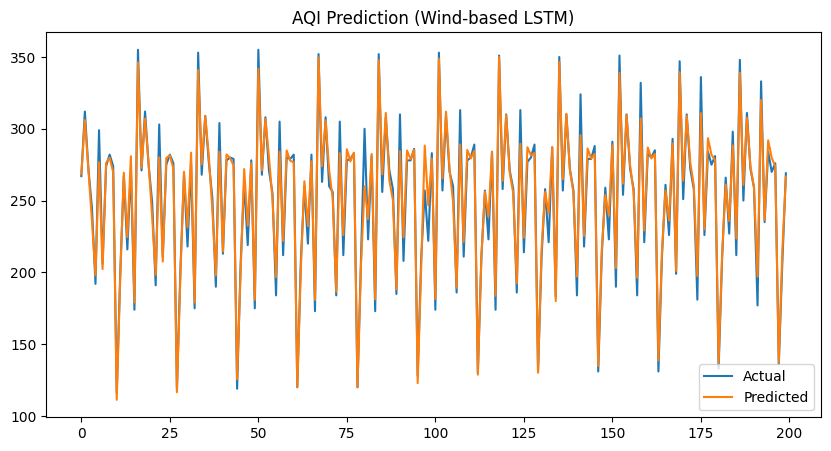

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_true[:200], label="Actual")
plt.plot(pred[:200], label="Predicted")
plt.legend()
plt.title("AQI Prediction (Wind-based LSTM)")
plt.show()